In [60]:
print("Hello from Jupyter in VS Code!")

Hello from Jupyter in VS Code!


In [61]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))
housing = load_housing_data()

In [62]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [63]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [64]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [65]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


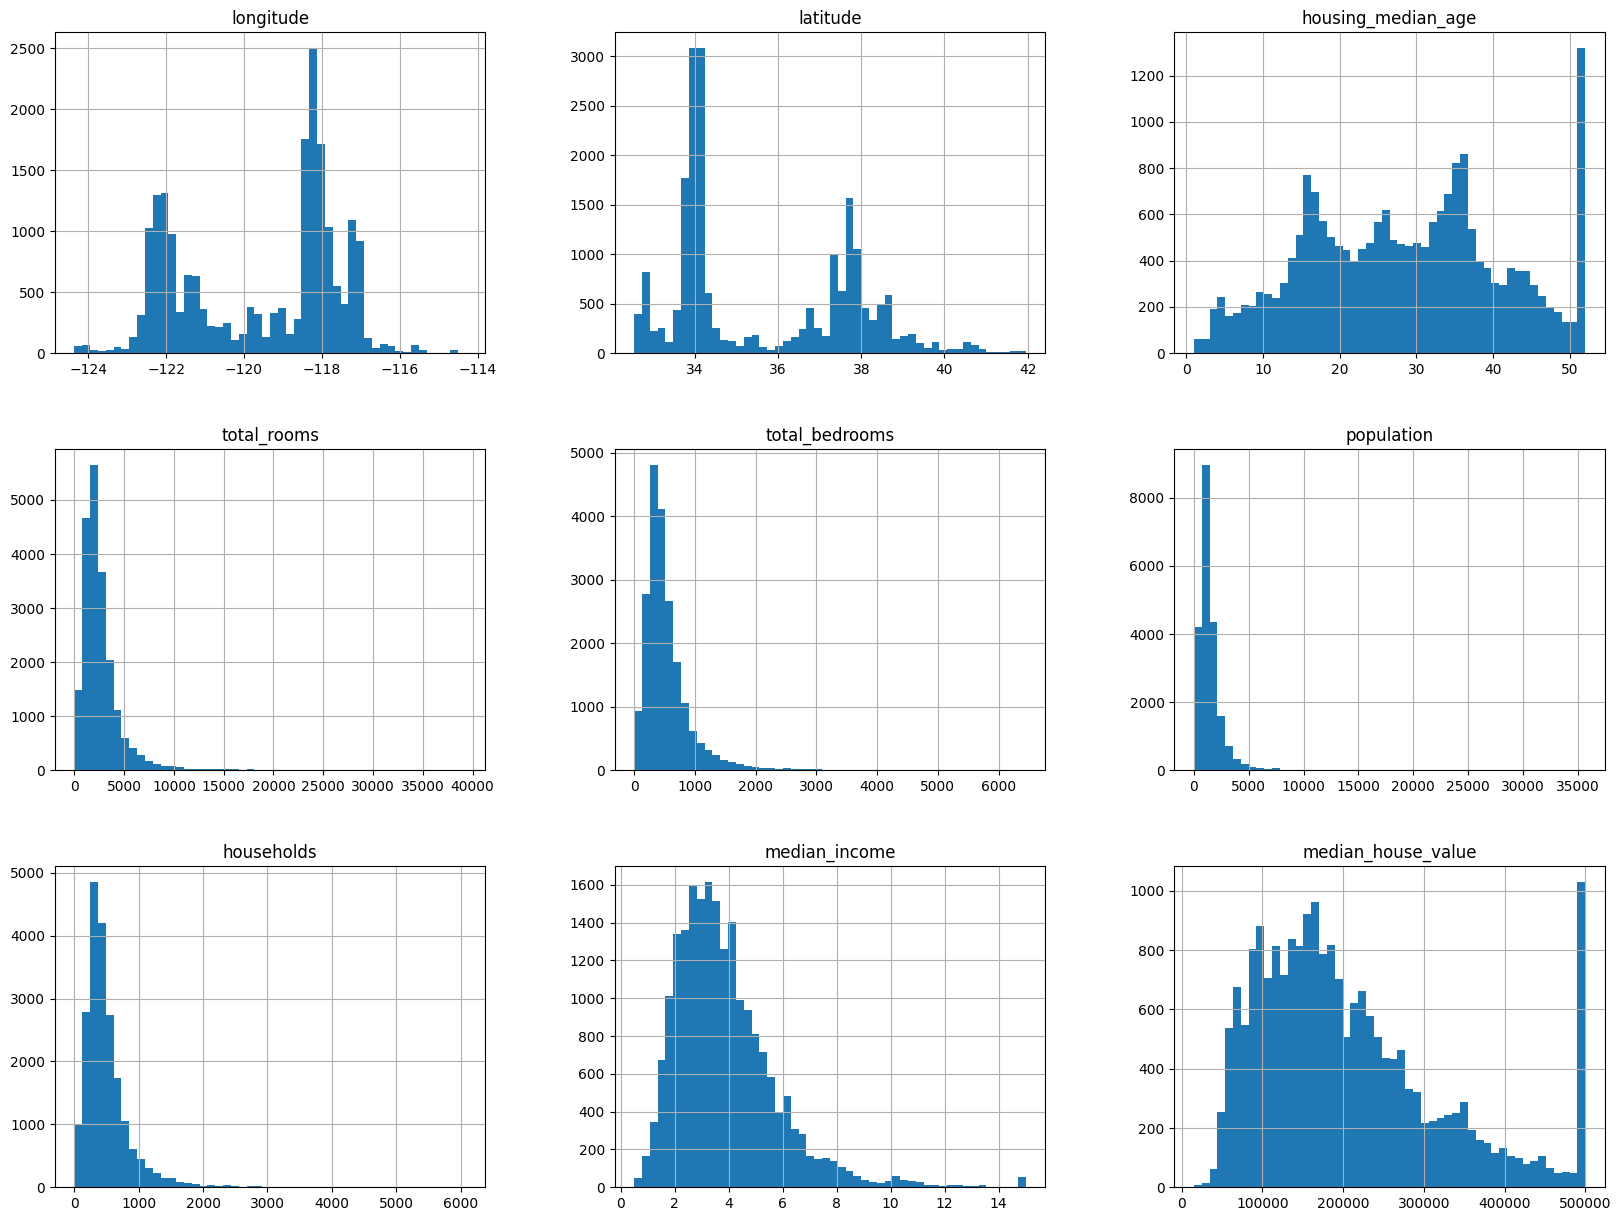

In [66]:
import matplotlib.pyplot as plt
housing.hist(bins = 50, figsize = (20, 15))
plt.show()

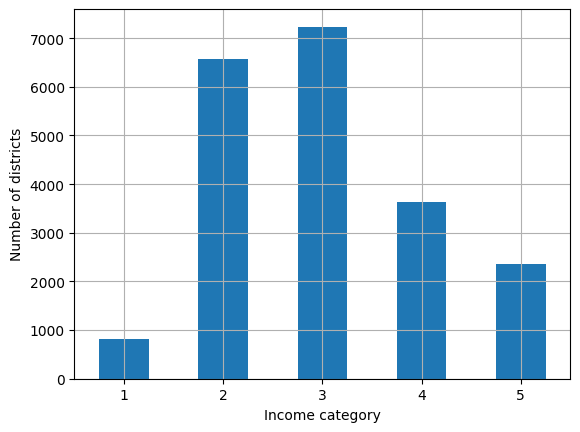

In [67]:

import numpy as np

housing["income_cat"] = pd.cut(
	housing["median_income"],
	bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
	labels=[1, 2, 3, 4, 5]
)

housing["income_cat"].value_counts().sort_index().plot.bar(rot = 0, grid = True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

# create the test set
from sklearn.model_selection import train_test_split
strat_train_set, strat_test_set = train_test_split(
	housing,
	test_size=0.2,
	stratify=housing["income_cat"],
	random_state=42
)

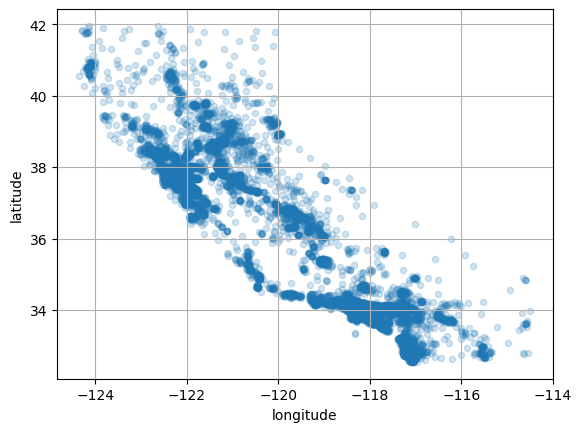

In [68]:
#Data visualization
housing = strat_train_set.copy()
housing.plot(kind = "scatter", x = "longitude", y="latitude", grid = True, alpha = 0.2)
plt.show()

In [69]:
# checking or correlation

# checking or correlation (use only numeric columns to avoid string conversion errors)
numeric_housing = housing.select_dtypes(include=["number"])
corr_matrix = numeric_housing.corr()

corr_matrix["median_house_value"].sort_values(ascending=False)


median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

In [70]:
# so we can also experiment with attriute by combing them to have a better correlation with the median_income.
# okay, so I was wrong. it is not for better correlation some of the ttributes are not useful or have no meaning until compared with other attributes and better use and info
housing["room per house"] = housing["total_rooms"] / housing["households"]
housing["bedroom ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people per house"] = housing["population"]/housing["households"]


# now look at the correlation again
numeric_housing = housing.select_dtypes(["number"])
corr_matrix = numeric_housing.corr()
corr_matrix["median_house_value"]

longitude            -0.050859
latitude             -0.139584
housing_median_age    0.102175
total_rooms           0.137455
total_bedrooms        0.054635
population           -0.020153
households            0.071426
median_income         0.688380
median_house_value    1.000000
room per house        0.143663
bedroom ratio        -0.256397
people per house     -0.038224
Name: median_house_value, dtype: float64

In [71]:
# After the stratified split
housing = strat_train_set.drop("median_house_value", axis=1)  # features only
housing_labels = strat_train_set["median_house_value"].copy()  # target only

In [72]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY
18031,<1H OCEAN
6753,<1H OCEAN


In [73]:
# so it is time trnasformation pipeline
'''Missing values in numerical features will be imputed by replacing
them with the median, as most ML algorithms don’t expect missing
values. In categorical features, missing values will be replaced by the
most frequent category.
The categorical feature will be one-hot encoded, as most ML
algorithms only accept numerical inputs.
A few ratio features will be computed and added: bedrooms_ratio,
rooms_per_house, and people_per_house. Hopefully these will
better correlate with the median house value, and thereby help the ML
models.
A few cluster similarity features will also be added. These will likely
be more useful to the model than latitude and longitude.
Features with a long tail will be replaced by their logarithm, as most
models prefer features with roughly uniform or Gaussian distributions.
All numerical features will be standardized, as most ML algorithms
prefer when all features have roughly the same scale.'''

# the experimantaion of the attributs combination we did is used here so that we dont have to recreat them all the time
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
# the custom tranformwr to be used
from sklearn.cluster import KMeans
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters = 10, gamma = 1.0, random_state = None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight = None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self # always self
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma = self.gamma)
    
    def get_feature_names_out(self, names = None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]
    

# now the pipeline

# 2. Ratio function and name helper
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # the ratio column

# 3. The three pipelines you need
ratio_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(column_ratio, feature_names_out=ratio_name),
    StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# 4. ClusterSimilarity instance
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)

# 5. Full preprocessing pipeline
preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline, ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline, ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline, ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                           "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
remainder=default_num_pipeline)  # passes remaining numeric columns through default_num_pipeline




In [74]:
# to applt all the tranfoamtion
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__income_cat'],
      dtype=object)

Selecting and training the Model!
Train and Evalate on the Traing set

In [75]:
# you decide to train a very basic regression model to get started:
from sklearn.linear_model import LinearRegression
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)


,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [76]:
# done! You now have a working linear regression model
#now we try it out on the training set and compare them on the labels

housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)


array([250400., 395000., 127400.,  87900., 332800.])

In [77]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

comparing the values we can tll that there is a lot of big difference. the predition is way off for thr 1st one especially

remember that we chose RMSE as out performance measure on the whole trining set using Scikit learn's root_mean_squared_error() function. with suared argument set to False

In [78]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse


68300.88727399785

The median housing values from 120 ro 265 thousand dollars and here we have an error of 68 toudands dollars. this is very bad and it is an examle of a underfitting model, a model underfitting the training data, this happens when the features do not provide enough information to make good predictions, or that the model is not powerful enough. The main ways to fix underfitting are to select a more powerful model, to feed the training
algorithm with better features, or to reduce the constraints on the model.
This model is not regularized, which rules out the last option. You could try
to add more features, but first you want to try a more complex model to see
how it does.

In [79]:
# okay so we are going with the first option, and e are using DecisionTreeRegressor
# it is a powerful model capable of finding nonlinear relationships in the data(decision trees)
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state = 42))
tree_reg.fit(housing, housing_labels)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [80]:
# now that the model is trined , you evaluate ot on the training set:
housing_predictions = tree_reg.predict(housing)
tree_rsme = root_mean_squared_error(housing_labels, housing_predictions)
tree_rsme

0.0

wiat, what no error at all Could this model really be absolutely perfect?
Of course, it is much more likely that the model has badly overfit the data.
How can you be sure? As you saw earlier, you don’t want to touch the test
set until you are ready to launch a model you are confident about, so you
need to use part of the training set for training and part of it for model
validation.


BETTER EVALUATION USING CROSS EVALUATION
on way to evaluate the decision model is to use the train_test_split() function to split the training set into smaller training set and a validation set. then train your models against the smaller trainging set and evaluate against the validation set. it is bit of effor. but nothing too difficult, and it would work fairly well. 

Another option is the k-fold Cross Validation method. The following code randomly splits the training set into 10 nonoverlapping subsets called FOLDS, then it trains and evaluates the decision tree model 10 times, picking a different fold for evluation every time and using the other 9 folds for training.
the model is trained 10 times, each time using 9 folds as the training set and 1 fold as the validation set, with a different fold been used for validation in each iteration. the spotlight evalution moves fro one fold to another each time.

In [81]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels, scoring = "neg_root_mean_squared_error", cv=10)

WARNING
sckit learn assumes that higherbscore equals better model
but RSME wroks the opposite way, lower RSME quals better model
why the neg_root_mean_squared_error exists:
RSME is a cost/loss function;
pefect model -- RMSE=0
Worse model--RSME increases

sklearn cross validation tools are designed around a different convention, they treat scores as utility functions where higher is better. This is useful because many optimization algorithms(hyperparameter tuning, etc) are built to maximize the score.

but RMSE goes the oppsite direction, you want to minimze it.
to make everything consistent inside sklearn(the higher the beeter the model), when u ask for RMSE or MSE in cross-validation, they return the negative of the error, and to cancel the minus sign results we put minus at the front to the function.  Inconlusion the CV is just returning the negative oof the RSME

In [82]:
# now the results
pd.Series(tree_rmses).describe()



count       10.000000
mean     66532.303625
std       1618.346537
min      64992.375699
25%      65378.062045
50%      65568.310266
75%      68216.420613
max      68843.320383
dtype: float64

now the decision tree doesnot look good as it did earlier. it seems to perform almost as poorly as the regression model did.
and note mean in the above result means the averag RSME across 10 folds.
and the std- standard deviation tells us how much the RMSE varies from fold to fold - in other words, how stable/ consistent the model's performance is across different subsets of the data. in brief it is a measure of how this estimate(RMSE) is.
NOTE: the relative error or relative error of the RMSE was calculated by dividing RMSE/average value of the target.

The decision tree has an RMSE of about 66,868, with a
standard deviation of about 2,061. You would not have this information if
you just used one validation set. But cross-validation comes at the cost of
training the model several times, so it is not always feasible.
If you compute the same metric for the linear regression model, you will
find that the mean RMSE is 69,858 and the standard deviation is 4,182. So
the decision tree model seems to perform very slightly better than the linear
model, but the difference is minimal due to severe overfitting. We know
there’s an overfitting problem because the training error is low (actually
zero) while the validation error is high.
Let’s try one last model now: the RandomForestRegressor. As you will
see in Chapter 7, random forests work by training many decision trees on
random subsets of the features, then averaging out their predictions. Such
models composed of many other models are called ensembles: they are
capable of boosting the performance of the underlying model (in this case,
decision trees). The code is much the same as earlier:

In [83]:


# now trying the RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(n_estimators = 5, max_depth = 10, random_state = 42))

forest_rmses = -cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv = 10)
     
pd.Series(forest_rmses). describe()





count       10.000000
mean     52779.262630
std       1182.414800
min      50998.431481
25%      52215.669508
50%      52532.166989
75%      53352.209315
max      54962.526999
dtype: float64

Wow, this is much better: random forests really look very promising for this
task! However, if you train a RandomForest and measure the RMSE on the
training set, you will find roughly 17,474: that’s much lower, meaning that
there’s still quite a lot of overfitting going on. Possible solutions are to
simplify the model, constrain it (i.e., regularize it), or get a lot more training
data. Before you dive much deeper into random forests, however, you
should try out many other models from various categories of machine
learning algorithms (e.g., several support vector machines with different
kernels, and possibly a neural network), without spending too much time
tweaking the hyperparameters. The goal is to shortlist a few (two to five)
promising models.

FINE-TUNE YOUR MODEL
Let us assume that you have a shortlis of promising models. you now need to fine-tune them. Lets look at a few ways you can do that.


Grid Search
One option is to fiddle with the hyperparameters manually, until you find a great combination of hyperparameters values. This would be very tediuos work, and you may not have time to explore many combinations

Instead, you can see Scikit-Learn's GrisSearchCV class to search for you. All you need to do is tell it whcih hyperparameters values. For hyperparameters values. 

For example, the following code searches for the best combinaion of pyerparameter values for the RandomForestRegressor:





In [84]:
'''from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
full_pipeline = Pipeline([
    ("preprocessing", preprocessing), ("random_forest", RandomForestRegressor(random_state=42))
])
param_grid = [
    {'preprocessing__geo__n_clusters': [5,8,10],
     'random_forest__max_features': [4,6,8]},
    {'preprocessing__geo__n_clusters': [10,15],
      'random_forest__max_features': [6,8,10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring = 'neg_root_mean_squared_error', n_jobs=-1, verbose = 2)

grid_search.fit(housing, housing_labels)'''

'from sklearn.model_selection import GridSearchCV\nfrom sklearn.pipeline import Pipeline\nfull_pipeline = Pipeline([\n    ("preprocessing", preprocessing), ("random_forest", RandomForestRegressor(random_state=42))\n])\nparam_grid = [\n    {\'preprocessing__geo__n_clusters\': [5,8,10],\n     \'random_forest__max_features\': [4,6,8]},\n    {\'preprocessing__geo__n_clusters\': [10,15],\n      \'random_forest__max_features\': [6,8,10]},\n]\ngrid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring = \'neg_root_mean_squared_error\', n_jobs=-1, verbose = 2)\n\ngrid_search.fit(housing, housing_labels)'

notice that you can refer to any hyperperameter of any estimator ina pipeline, even if this estimator is nested deep inside several pipelines and column ransformers. when ur model is inside a pipeline(or nested even deeper), you can still tune any hyperparameter by using thi naming convention:

step_name__hyperparametter_name
if nested deeper:
step_name__sub_step_name__hyperparamter
Examples from the book:

'preprocessing__geo__n_clusters'
→ preprocessing (the ColumnTransformer step)
→ geo (the ClusterSimilarity transformer inside it)
→ n_clusters (its hyperparameter)
'random_forest__max_features'
→ random_forest (the model step in the pipeline)
→ max_features (its hyperparameter)

Scikit-learn automatically splits the string at each __ and walks down the pipeline structure to find and set that exact parameter.
There are two dictionaries in this param_grid, so GridSearchCV will first
evaluate all 3 × 3 = 9 combinations of n_clusters and max_features
hyperparameter values specified in the first dict, then it will try all 2 × 3 =6 combinations of hyperparameter values in the second dict. So in total the
grid search will explore 9 + 6 = 15 combinations of hyperparameter values,
and it will train the pipeline 3 times per combination, since we are using 3-
fold cross validation. This means there will be a grand total of 15 × 3 = 45
rounds of training! It may take a while, but when it is done you can get the
best combination of parameters like this:

In [85]:
#grid_search.best_params_

In this example, the best model is obtained by setting n_clusters to 15 and
setting max_features to 8.
TIP
Since 15 is the maximum value that was evaluated for n_clusters, you should
probably try searching again with higher values; the score may continue to improve.
You can access the best estimator using grid_search.best_estimator_.
If GridSearchCV is initialized with refit=True (which is the default), then
once it finds the best estimator using cross-validation, it retrains it on the
whole training set. This is usually a good idea, since feeding it more data
will likely improve its performance.
The evaluation scores are available using grid_search.cv_results_. This
is a dictionary, but if you wrap it in a DataFrame you get a nice list of all
the test scores for each combination of hyperparameters and for each crossvalidation
split, as well as the mean test score across all splits:

In [86]:
'''cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending =False, inplace = True)
#[...] # change column names to fit on this page, and show rmse = -score
cv_res.head() # note: the 1st column is the row ID'''

'cv_res = pd.DataFrame(grid_search.cv_results_)\ncv_res.sort_values(by="mean_test_score", ascending =False, inplace = True)\n#[...] # change column names to fit on this page, and show rmse = -score\ncv_res.head() # note: the 1st column is the row ID'

In [87]:
'''# to make ur output look like that of the book, you can do this:
# and the above result is like that because you are showing the raw resluts, while the book was showing the important parts which is the three fold and also the avg rmse for them. and also the -score

cv_res = pd.DataFrame(grid_search.cv_results_)

#1. extract the tuned pyperparameters from the 'params' column
#(each row's 'params' is a dict like {'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6})


cv_res['n_clusters'] = cv_res['params'].apply(lambda x: x.get('preprocessing__geo__n_clusters', None))
cv_res['max_features'] = cv_res['params'].apply(lambda x: x.get('random_forest__max_features', None))

#2. Create positive rmse columns (flip the negative signs)
cv_res['mean_test_rmse'] = -cv_res['mean_test_score']

# for each fold (asuming cv=3, so split0, split1, split2)
cv_res['split0'] = -cv_res['split0_test_score']
cv_res['split1'] = -cv_res['split1_test_score']
cv_res['split2'] = -cv_res['split2_test_score']

# 3. select and rename only the columns we want to show(to fit on page)
# This is what "change column names to fit on this page" refers to

display_cols = [
    'n_clusters',
    'max_features',
    'split0',
    'split1',
    'split2',
    'mean_test_rmse'

]

# sort by best mean RMSE (lowest +ve number first)
cv_res_sorted = cv_res.sort_values('mean_test_rmse', ascending = True)

# show the top few
cv_res_sorted[display_cols].head(5)'''

'# to make ur output look like that of the book, you can do this:\n# and the above result is like that because you are showing the raw resluts, while the book was showing the important parts which is the three fold and also the avg rmse for them. and also the -score\n\ncv_res = pd.DataFrame(grid_search.cv_results_)\n\n#1. extract the tuned pyperparameters from the \'params\' column\n#(each row\'s \'params\' is a dict like {\'preprocessing__geo__n_clusters\': 15, \'random_forest__max_features\': 6})\n\n\ncv_res[\'n_clusters\'] = cv_res[\'params\'].apply(lambda x: x.get(\'preprocessing__geo__n_clusters\', None))\ncv_res[\'max_features\'] = cv_res[\'params\'].apply(lambda x: x.get(\'random_forest__max_features\', None))\n\n#2. Create positive rmse columns (flip the negative signs)\ncv_res[\'mean_test_rmse\'] = -cv_res[\'mean_test_score\']\n\n# for each fold (asuming cv=3, so split0, split1, split2)\ncv_res[\'split0\'] = -cv_res[\'split0_test_score\']\ncv_res[\'split1\'] = -cv_res[\'split1

The mean test RMSE score for the best model is 44,042, which is better
than the score you got earlier using the default hyperparameter values
(which was 47,019). Congratulations, you have successfully fine-tuned your
best model!

RANDOMIZED SEARCH


In [88]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(random_state=42))
])

# ADD limits to make randomforest MUCH faster(key change)!
param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50), #THE ORIGINAL
                  'random_forest__max_features': randint(low = 2, high=20), # THE ORIGINAL
                  # ADD HESE TO CONTROL RF SIZE/SPEED
                  'random_forest__n_estimators':randint(low=20, high=80), # fewer trees for faster training
                  'random_forest__max_depth': [10,15,20,None]} # shallower trees for faster training
        

rnd_search = RandomizedSearchCV(
    full_pipeline, 
    param_distributions=param_distribs,
    n_jobs=-1, #CRUCIAL: use all CPU cores!
      n_iter=10, # keep 10, or reduce to 5 for even faster test
        cv=3,
        verbose=2, # shows progress
    scoring='neg_root_mean_squared_error', refit=True, random_state=42)

rnd_search.fit(housing, housing_labels)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'preprocessing__geo__n_clusters': <scipy.stats....001DFF429B890>, 'random_forest__max_depth': [10, 15, ...], 'random_forest__max_features': <scipy.stats....001DFF0F19AE0>, 'random_forest__n_estimators': <scipy.stats....001DFF0F185A0>}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


analyzing the best models and their errors

In [89]:
final_model = rnd_search.best_estimator_ # includes preprocessing
feature_importance = final_model["random_forest"].feature_importances_
feature_importance.round(2)

array([0.05, 0.03, 0.04, 0.01, 0.01, 0.01, 0.01, 0.14, 0.03, 0.03, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.03, 0.02, 0.02, 0.02, 0.03,
       0.02, 0.02, 0.02, 0.01, 0.03, 0.02, 0.02, 0.01, 0.02, 0.02, 0.02,
       0.04, 0.01, 0.05, 0.  , 0.  , 0.  , 0.01, 0.07])

In [90]:
sorted(zip(feature_importance,
    final_model["preprocessing"].get_feature_names_out()),
    reverse=True)

[(np.float64(0.13802146724181585), 'log__median_income'),
 (np.float64(0.06934862058559016), 'remainder__income_cat'),
 (np.float64(0.05462776671621013), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.04859748529008391), 'bedrooms__ratio'),
 (np.float64(0.04090771260447152), 'geo__Cluster 25 similarity'),
 (np.float64(0.03596883189323684), 'people_per_house__ratio'),
 (np.float64(0.03362985917232541), 'rooms_per_house__ratio'),
 (np.float64(0.03286150867271635), 'geo__Cluster 13 similarity'),
 (np.float64(0.031033812275335845), 'geo__Cluster 9 similarity'),
 (np.float64(0.030865343917899427), 'geo__Cluster 0 similarity'),
 (np.float64(0.02659695409172195), 'geo__Cluster 1 similarity'),
 (np.float64(0.026351001156379925), 'geo__Cluster 18 similarity'),
 (np.float64(0.023873214947702642), 'geo__Cluster 14 similarity'),
 (np.float64(0.023255964625586045), 'geo__Cluster 6 similarity'),
 (np.float64(0.022727199853556104), 'geo__Cluster 7 similarity'),
 (np.float64(0.022707844912458842), 'ge

In [91]:
# evaluate ur system on test set
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
final_rmse

42919.83536140057

95% Confidence Interval for generalization error

In [92]:
from scipy import stats
confidence = 0.95
squared_error = (final_predictions - y_test)**2
np.sqrt(stats.t.interval(confidence, len(squared_error) - 1,
                         loc = squared_error.mean(),
                         scale=stats.sem(squared_error)))

array([40790.84037179, 44948.10203627])

so the next phase is the project prelaunch phase: you need to present u solution(highlighting what u have learnt what worked and what did not, what assumptions were made, and what ur system's limitation are), document everything, and create nice presentations with clear visualizations, and easy-to-remember statements(e.g. "the median income is the number one predictor o housing pries). in this carnifolia housing example, the final performance of the system of the system is not much than the experts' price estimates, which were often off by 30%, but it may still be a good idea to launch it, especially if this frees up some time for time for the experts so they can wrok on more interesting and productive tasks.

Launch, Monitor, and Maintain Your System
this phase about ur solution ready for production(eg. polish the code, write documentation, and test, and so on). Then you can deploy ur model to ur production environment. The most basic way to dot his is just to save the best odel you trained, trnasfer the file to your production environment, and load it. To save the model, you can use the the joblib library like this:

In [93]:
import joblib

#joblib.dump(final_model, "my_carnifonia_housing_model.pkl")
joblib.dump(full_pipeline, 'full_pipeline.pkl')

['full_pipeline.pkl']

TIP
It’s often a good idea to save every model you experiment with so that you can come
back easily to any model you want. You may also save the cross-validation scores and
perhaps the actual predictions on the validation set. This will allow you to easily
compare scores across model types, and compare the types of errors they make.

Once ur model is transferred to production, you can load and use it. For this you must first import any custom classes and functions the model and pipeline relies on(which means transferring the code to production), then load the model using joblib and use it to make predictions, and it is also important to save ur preprocessing pipeline too:

In [94]:
'''in the production code(new file and server)
from the my_custom_transformer(filename) import ClusterSimilarity

# load the saved pipeline
# import joblib
# model = joblib.load('compltepath to the model')
# 
# get new data(eg Dfrom api, database, from)
# new_house = {}
# 
# predict - no manual preprocesing
# price_prediction = model.predict([list])'''

"in the production code(new file and server)\nfrom the my_custom_transformer(filename) import ClusterSimilarity\n\n# load the saved pipeline\n# import joblib\n# model = joblib.load('compltepath to the model')\n# \n# get new data(eg Dfrom api, database, from)\n# new_house = {}\n# \n# predict - no manual preprocesing\n# price_prediction = model.predict([list])"

EXERCISES!!!
1. Try a support vector machine regressor (sklearn.svm.SVR) with
various hyperparameters, such as kernel="linear" (with various
values for the C hyperparameter) or kernel="rbf" (with various
values for the C and gamma hyperparameters). Note that support vector
machines don’t scale well to large datasets, so you should probably
train your model on just the first 5,000 instances of the training set and
use only 3-fold cross-validation, or else it will take hours. Don’t worry
about what the hyperparameters mean for now; we’ll discuss them in
Chapter 5. How does the best SVR predictor perform?

In [95]:
import pandas as pd
subset_size = 5000
subset_idx = housing.sample(n=subset_size, random_state=42).index

X_small = housing.loc[subset_idx]
y_small = housing_labels.loc[subset_idx]

# This is random smapling without replacement

In [96]:
'''#DEFINE YOUR PIPELINE
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

svr_pipeline = Pipeline([
    ('Preprocessing', preprocessing),#ur existin pipeline
    ('svr', SVR())
])'''

"#DEFINE YOUR PIPELINE\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.svm import SVR\n\nsvr_pipeline = Pipeline([\n    ('Preprocessing', preprocessing),#ur existin pipeline\n    ('svr', SVR())\n])"

In [97]:
'''from scipy.stats import loguniform, uniform
# cross validation!
param_dist= [
                {'svr__kernel': ['linear'],
                 'svr__C': loguniform(1e-2, 1e3),
                 },
                 {'svr__kernel': ['rbf'],
                  'svr__C': loguniform(1e-2,1e3),
                  'svr__gamma': loguniform(1e-4, 1)}
                 ]

rnd_srch = RandomizedSearchCV(
    svr_pipeline,param_distributions=param_dist, n_iter=10, cv = 3, n_jobs=-1, verbose = 2, 
    scoring='neg_root_mean_squared_error', random_state = 42
)

rnd_srch.fit(X_small, y_small)'''

"from scipy.stats import loguniform, uniform\n# cross validation!\nparam_dist= [\n                {'svr__kernel': ['linear'],\n                 'svr__C': loguniform(1e-2, 1e3),\n                 },\n                 {'svr__kernel': ['rbf'],\n                  'svr__C': loguniform(1e-2,1e3),\n                  'svr__gamma': loguniform(1e-4, 1)}\n                 ]\n\nrnd_srch = RandomizedSearchCV(\n    svr_pipeline,param_distributions=param_dist, n_iter=10, cv = 3, n_jobs=-1, verbose = 2, \n    scoring='neg_root_mean_squared_error', random_state = 42\n)\n\nrnd_srch.fit(X_small, y_small)"

In [98]:
'''best_svr_rmse = -rnd_srch.best_score_

best_svr_rmse'''

'best_svr_rmse = -rnd_srch.best_score_\n\nbest_svr_rmse'

so answering the question, the performance of the SVR is much more worse than that of randomforest and linear regression. 

3. Try adding a SelectFromModel transformer in the preparation pipeline
to select only the most important attributes.

solution:
we already have ur full_pipeline(preprocessing + random_forest)
ur best RandomForestModel (earlier from finetuning)

In [104]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# 1. Use the TUNED and FITTED pipeline from your search
best_pipeline = rnd_search.best_estimator_   # ← this is the key: it's already fitted!

# 2. Extract the fitted Random Forest (has importances)
best_rf = best_pipeline.named_steps['random_forest']

# 3. Extract the best random_forest params (fix KeyError)
best_rf_params = {
    key.replace('random_forest__', ''): value
    for key, value in rnd_search.best_params_.items()
    if key.startswith('random_forest__')
}

# 4. Build the improved pipeline
improved_pipeline = Pipeline([
    ('preprocessing', best_pipeline.named_steps['preprocessing']),  # tuned & fitted preprocessing
    
    ('selector', SelectFromModel(
        estimator=best_rf,         # fitted RF → has importances
        threshold='median'       # safe default
    )),
    
    ('random_forest', RandomForestRegressor(**best_rf_params))  # new RF with best params
])

# 5. Evaluate
scores = cross_val_score(
    improved_pipeline,
    housing, housing_labels,   # full data OK now, or use X_small for speed
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    error_score='raise'
)

rmse_selected = -scores.mean()
print(f"RMSE with selected features: {rmse_selected:,.0f}")

# 6. Features kept (after one fit)
improved_pipeline.fit(housing, housing_labels)
# After improved_pipeline.fit(housing, housing_labels)
selector = improved_pipeline.named_steps['selector']

n_input_to_selector = improved_pipeline.named_steps['preprocessing'].transform(housing).shape[1]
n_kept = selector.get_support().sum()

print(f"Features kept: {n_kept} out of {n_input_to_selector} (after preprocessing)")

RMSE with selected features: 44,171
Features kept: 21 out of 41 (after preprocessing)


from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class MyCustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, some_parameter=True):
        self.some_parameter = some_parameter
    
    def fit(self, X, y=None):
        # Learn something from the data here (or do nothing)
        # Always return self
        return self
    
    def transform(self, X):
        # Apply the transformation to X and return the result
        # Do NOT modify X in place; return a new object
        X_new = X.copy()  # good practice for pandas DataFrames
        # ... do your transformation on X_new ...
        return X_new


Key Points to Remember

Always inherit from BaseEstimator, TransformerMixin.
__init__ is for hyperparameters (things you want to tune).
fit learns from data (e.g., which columns are numeric, means/std for scaling, etc.). Return self.
transform applies the transformation. Never modify X in place — copy it first if needed.
If your transformer doesn't need to learn anything (stateless), fit can just return self.
Return the same type you received (usually pandas DataFrame or numpy array).

The transformers look different from each other because they do different things — but they all follow this same skeleton.

Exercise 4
Try creating a custom transformer that trains a k-nearest neighbors
regressor (sklearn.neighbors.KNeighborsRegressor) in its fit()
method, and outputs the model’s predictions in its transform()
method. Then add this feature to the preprocessing pipeline, using
latitude and longitude as the inputs to this transformer. This will add a
feature in the model that corresponds to the housing median price of
the nearest districts.

In [ ]:
#Using the clusterSimilarity as an illustration
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters = 10, gamma = 1.0, random_state = None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state= random_state

    def fit(self, X, y = None):


In [4]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import BaseEstimator, TransformerMixin

class Custom_Transformes9 (BaseEstimator, TransformerMixin):

    def __init__(self, n_neighbors = 5,
                 n_neighbours = 10,
                 weights = 'uniform',
                 metrics = 'euclidean',
                 add_original = True,
                 output_column = 'geo_column'):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.metrics = metrics
        self.add_original = add_original
        self.output_column = output_column


    def fit(self, X, y = None):
        #Extracting latitude and longitude safely
        if isinstance(X, pd.DataFrame):

            if 'latitude' not in X.columns or 'longitude':
                raise ValueError('Input must contain latitude and longitude')
                
            X_geo = X[['latitude', 'longitude']].to_numpy()


        else:
            if X.shape[1] != 2:
                raise ValueError('When input is numpy array, it must have exactly 2 columns: latitude and longitude')
                
            X_geo = X.copy()

            # training the model with latitude and longitude
        self.model_ = KNeighborsRegressor(
            n_neighbors=self.n_neighbors,
            weights=self.weights,
            metrics = self.metrics

        )
        self.model_.fit(X_geo,y)


        return self

    def transform(self,X):
        if self.model_ is None:
            raise RuntimeError('you must call .fit(X,y)')

        if isinstance(X, pd.DataFrame):
            if 'latitude' not in X.columns or 'longitude' not in X.columns:
                raise ValueError('Input must contain latitude and longitude')
            
            X_geo = X[['latitude', ' longitude']]
            result =X.copy()

        else:
            if X.shape[1] != 2:
                raise ValueError('When input is numpy array, it must have exactly 2 columns: latitude and longitude')
                
            X_geo = X.copy()
            result = X.copy()

            

        self.model_.predict(X_geo)

       # Add new feature
        if isinstance(result, pd.DataFrame):
            result[self.output_column] = predictions
        else:
            predictions = predictions.reshape(-1, 1)
            result = np.hstack([result, predictions])

        if self.add_original:
            return result
        else:
            if isinstance(result, pd.DataFrame):
                return result[[self.output_column]]
            else:
                return predictions

In [ ]:
# The next thing is to add the features to the preprocessing pipeline and see if it improves the model performance.